# Concise Vehicle Sales SQL & Matplotlib Pipeline
This notebook contains a clean, optimized, and heavily commented implementation of the data cleaning, MySQL database ingestion, and SQL-based analytics pipeline. 

### **What we did in this version:**
1. **Concised Code:** Combined redundant code, simplified cleaning loops, and reduced script length while maintaining exactly the same functionality.
2. **Removed Pandas & NumPy:** Relies solely on Python's built-in standard libraries (`csv`, `datetime`) for lightweight data processing.
3. **Connected to XAMPP MySQL:** Performs schema setups and batch insertions on port `33007`.
4. **Added Data Visualizations (Matplotlib):** Reads query results directly into standard Python structures and plots visual charts with `matplotlib.pyplot` without any pandas overhead.
5. **Explanatory Comments:** Added line-by-line comments detailing every operation.

### **Dependencies Installation**
Run this cell to install `mysql-connector-python`, `tabulate`, and `matplotlib` if they are missing from your environment.

In [17]:
# !pip install mysql-connector-python tabulate matplotlib

## 1. Environment Setup & Schema Creation
Here, we initialize connection parameters to the XAMPP MySQL database service (port `33007`), define our raw dataset path, and build the database and target schema.

In [18]:
import os
import csv
import datetime
import mysql.connector
from mysql.connector import Error
from tabulate import tabulate
import matplotlib.pyplot as plt

# Database & CSV configuration settings
DB_HOST, DB_PORT = "127.0.0.1", 33007
DB_USER, DB_PASSWORD, DB_NAME = "root", "", "vehicle_sales_db"
CSV_FILE_PATH = os.path.join("data", "car_prices.csv")
MAX_ROWS = int(input("Enter the maximum number of rows to Clean: "))  # Cap target records to ingest for performance

def setup_db_and_table():
    """Establishes connection to MySQL and builds the database/table schema if missing."""
    try:
        # Connect to the root server
        conn = mysql.connector.connect(host=DB_HOST, port=DB_PORT, user=DB_USER, password=DB_PASSWORD)
        cursor = conn.cursor()
        
        # Create the database and switch context
        cursor.execute(f"CREATE DATABASE IF NOT EXISTS {DB_NAME}")
        cursor.execute(f"USE {DB_NAME}")
        
        # Create the main vehicle sales table
        cursor.execute("""
            CREATE TABLE IF NOT EXISTS car_sales (
                id INT AUTO_INCREMENT PRIMARY KEY,
                year INT,
                make VARCHAR(50),
                model VARCHAR(100),
                trim VARCHAR(100),
                body VARCHAR(50),
                transmission VARCHAR(20),
                vin VARCHAR(50),
                state VARCHAR(10),
                `condition` FLOAT,
                odometer INT,
                color VARCHAR(50),
                interior VARCHAR(50),
                seller VARCHAR(255),
                mmr INT,
                sellingprice INT,
                saledate DATE,
                saleday VARCHAR(20),
                INDEX idx_vin (vin)
            ) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4;
        """)
        print(f"[+] Connection Success. Database '{DB_NAME}' and table 'car_sales' verified.")
        cursor.close()
        conn.close()
    except Error as e:
        print(f"[-] DB Setup error: {e}. Make sure XAMPP is running on port 33007.")

setup_db_and_table()

[+] Connection Success. Database 'vehicle_sales_db' and table 'car_sales' verified.


## 2. Concise Date Parsing & Data Cleaning Rules
We define the parsing and validation rules using only pure Python to scrub, title-case, check ranges, and prepare cells for insertion.

In [19]:
def parse_saledate(date_str):
    """Parses standard raw date formats including timezone offsets like GMT-0800 (PST)."""
    if not date_str:
        return None
    
    # Standardize GMT-0800 strings (e.g. "Tue Dec 16 2014 12:30:00 GMT-0800")
    parts = date_str.strip().split()
    if len(parts) >= 5:
        try:
            return datetime.datetime.strptime(f"{parts[1]} {parts[2]} {parts[3]} {parts[4]}", "%b %d %Y %H:%M:%S")
        except ValueError:
            pass
            
    # Fallback checks for ISO, slashed, or short date formats
    for fmt in ("%Y-%m-%d %H:%M:%S", "%Y-%m-%d", "%m/%d/%Y %H:%M", "%m/%d/%Y"):
        try:
            return datetime.datetime.strptime(date_str.strip(), fmt)
        except ValueError:
            continue
    return None

def clean_row(row):
    """Validates schema restrictions and cleans a single data row. Returns dict or None."""
    # Match missing cell values and standard placeholders
    placeholders = {'', '—', 'null', 'nan', 'none', 'n/a', 'na', '-', 'undefined'}
    
    # Ensure all columns have valid filled contents
    for key, val in row.items():
        if val is None or str(val).strip().lower() in placeholders:
            return None
            
    try:
        cleaned = {}
        
        # 1. Validate manufacturing year constraints
        year = int(row['year'].strip())
        if year < 1900 or year > datetime.datetime.now().year + 2:
            return None
        cleaned['year'] = year
        
        # 2. Standardize text casings
        cleaned['make'] = row['make'].strip().title()
        cleaned['model'] = row['model'].strip().title()
        cleaned['trim'] = row['trim'].strip()
        cleaned['body'] = row['body'].strip().title()
        cleaned['color'] = row['color'].strip().title()
        cleaned['interior'] = row['interior'].strip().title()
        cleaned['seller'] = row['seller'].strip()
        cleaned['state'] = row['state'].strip().upper()
        
        # 3. Handle transmission groups
        trans = row['transmission'].strip().lower()
        if 'auto' in trans:
            cleaned['transmission'] = 'automatic'
        elif 'man' in trans:
            cleaned['transmission'] = 'manual'
        else:
            return None
            
        # 4. Check VIN requirements
        vin = row['vin'].strip().upper()
        if len(vin) < 5 or not vin.isalnum():
            return None
        cleaned['vin'] = vin
        
        # 5. Parse numerical fields (non-negative)
        cond = float(row['condition'].strip())
        odo = int(row['odometer'].strip())
        mmr = int(row['mmr'].strip())
        sp = int(row['sellingprice'].strip())
        
        if cond < 0 or cond > 50 or odo < 0 or mmr < 0 or sp < 0:
            return None
            
        cleaned.update({'condition': cond, 'odometer': odo, 'mmr': mmr, 'sellingprice': sp})
        
        # 6. Parse and derive date parameters
        dt = parse_saledate(row['saledate'])
        if not dt:
            return None
        cleaned['saledate_obj'] = dt
        cleaned['saledate'] = dt.strftime("%Y-%m-%d")
        cleaned['saleday'] = dt.strftime("%A")
        
        return cleaned
    except (ValueError, KeyError, TypeError):
        return None

## 3. Data Ingestion Pipeline
Reads, cleans, chronologically sorts, and batch-inserts the records into MySQL. This keeps the database footprint small and maximizes performance.

In [20]:
def ingest_csv_data():
    """Performs chronological sorting and batch database ingestion from raw CSV."""
    if not os.path.exists(CSV_FILE_PATH):
        print(f"[-] Ingestion stopped: File not found at {CSV_FILE_PATH}")
        return
        
    print("[*] Scanning and scrubbing raw CSV...")
    cleaned_records = []
    scanned, skipped = 0, 0
    
    # Open raw file and stream records one-by-one
    with open(CSV_FILE_PATH, mode='r', encoding='utf-8', errors='ignore') as f:
        for row in csv.DictReader(f):
            scanned += 1
            cleaned = clean_row(row)
            if cleaned:
                cleaned_records.append(cleaned)
                if len(cleaned_records) == MAX_ROWS:
                    break
            else:
                skipped += 1
                
    print(f"    - Processed rows: {scanned:,} | Collected: {len(cleaned_records):,} | Skipped: {skipped:,}")
    
    # Sort data chronologically using the datetime objects
    print("[*] Sorting records chronologically by sale date...")
    cleaned_records.sort(key=lambda x: x['saledate_obj'])
    
    # Establish database transaction context
    print(f"[*] Ingesting records into MySQL database '{DB_NAME}'...")
    try:
        conn = mysql.connector.connect(host=DB_HOST, port=DB_PORT, user=DB_USER, password=DB_PASSWORD, database=DB_NAME)
        cursor = conn.cursor()
        
        # Clear table to avoid duplicate primary keys
        cursor.execute("TRUNCATE TABLE car_sales")
        
        # Bulk insert configuration
        insert_query = """
            INSERT INTO car_sales (
                year, make, model, trim, body, transmission, vin, state, 
                `condition`, odometer, color, interior, seller, mmr, 
                sellingprice, saledate, saleday
            ) VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
        """
        
        # Transform dictionary records to tuple format for MySQL
        insert_data = [
            (
                r['year'], r['make'], r['model'], r['trim'], r['body'], r['transmission'], r['vin'], r['state'],
                r['condition'], r['odometer'], r['color'], r['interior'], r['seller'], r['mmr'],
                r['sellingprice'], r['saledate'], r['saleday']
            ) for r in cleaned_records
        ]
        
        # Execute batch upload chunks of 5000
        batch_size = 5000
        for idx in range(0, len(insert_data), batch_size):
            cursor.executemany(insert_query, insert_data[idx:idx+batch_size])
            
        conn.commit()  # Commit transaction
        print(f"[+] Ingestion Complete! Successfully wrote {len(insert_data):,} records.")
        cursor.close()
        conn.close()
    except Error as e:
        print(f"[-] Database write failed: {e}")

ingest_csv_data()

[*] Scanning and scrubbing raw CSV...
    - Processed rows: 73,751 | Collected: 50,000 | Skipped: 23,751
[*] Sorting records chronologically by sale date...
[*] Ingesting records into MySQL database 'vehicle_sales_db'...
[+] Ingestion Complete! Successfully wrote 50,000 records.


## 4. Verification and Data Quality Checks (SQL)
We query the database server directly using standard SQL queries to inspect the data shape, verify null counts, and check field descriptions.

In [24]:
def run_sql_query(cursor, query):
    """Utility to run a query and fetch all results."""
    cursor.execute(query)
    if cursor.description:
        return cursor.fetchall()
    return None

query_samples = """
SELECT
    id,
    year, 
    make, 
    model,
    transmission,  
    sellingprice, 
    saledate, 
    saleday,
    YEAR(saledate) AS `Sale Year`, 
    MONTHNAME(saledate) AS `Sale Month`, 
    (sellingprice - mmr) AS `Profit/Loss`
FROM car_sales
"""

def verify_data_integrity():
    """Validates row counts, null values, and prints schema types using raw SQL."""
    try:
        conn = mysql.connector.connect(host=DB_HOST, port=DB_PORT, user=DB_USER, password=DB_PASSWORD, database=DB_NAME)
        cursor = conn.cursor(dictionary=True)
        
        # Query total size
        cursor.execute("SELECT COUNT(*) AS count FROM car_sales")
        total_rows = cursor.fetchone()['count']
        print(f"[1] Database Records Count: {total_rows:,}")
        
        # Query duplicate VINs
        cursor.execute("SELECT COUNT(*) - COUNT(DISTINCT vin) AS duplicate_vins FROM car_sales")
        print(f"[2] Duplicate VIN Count: {cursor.fetchone()['duplicate_vins']:,}")
        
        # Schema description table formatting
        cursor.execute("DESCRIBE car_sales")
        schema_info = [[col['Field'], col['Type'], col['Null'], col['Key']] for col in cursor.fetchall()]
        print("\n[3] Ingested Schema Description:")
        print(tabulate(schema_info, headers=['Field', 'Type', 'Null', 'Key'], tablefmt='psql'))
        
        # Display First 10 Rows
        print("\n[4] FIRST 10 ROWS (ORDER BY id ASC) ---")
        first_10 = run_sql_query(cursor, f"{query_samples} ORDER BY id ASC LIMIT 10")
        print(tabulate(first_10, headers='keys', tablefmt='psql', showindex=False))

        # Display Last 10 Rows
        print("\n[5] LAST 10 ROWS (ORDER BY id DESC) ---")
        last_10_desc = run_sql_query(cursor, f"{query_samples} ORDER BY id DESC LIMIT 10")
        last_10 = list(reversed(last_10_desc))
        print(tabulate(last_10, headers='keys', tablefmt='psql', showindex=False))
        
        cursor.close()
        conn.close()
    except Error as e:
        print(f"[-] SQL execution error: {e}")

verify_data_integrity()

[1] Database Records Count: 50,000
[2] Duplicate VIN Count: 85

[3] Ingested Schema Description:
+--------------+--------------+--------+-------+
| Field        | Type         | Null   | Key   |
|--------------+--------------+--------+-------|
| id           | int(11)      | NO     | PRI   |
| year         | int(11)      | YES    |       |
| make         | varchar(50)  | YES    |       |
| model        | varchar(100) | YES    |       |
| trim         | varchar(100) | YES    |       |
| body         | varchar(50)  | YES    |       |
| transmission | varchar(20)  | YES    |       |
| vin          | varchar(50)  | YES    | MUL   |
| state        | varchar(10)  | YES    |       |
| condition    | float        | YES    |       |
| odometer     | int(11)      | YES    |       |
| color        | varchar(50)  | YES    |       |
| interior     | varchar(50)  | YES    |       |
| seller       | varchar(255) | YES    |       |
| mmr          | int(11)      | YES    |       |
| sellingprice | int(

## 5. SQL Business Insights Dashboard (Console Tables)
We calculate the 5 core analytical metrics (volume, profitability, weekly trends, monthly trends, and transmission performance) using SQL queries and format them into visual text grids.

In [22]:
def print_reports_dashboard():
    """Runs database-side analytics SQL queries and outputs tabulated reports."""
    try:
        conn = mysql.connector.connect(host=DB_HOST, port=DB_PORT, user=DB_USER, password=DB_PASSWORD, database=DB_NAME)
        cursor = conn.cursor(dictionary=True)
        
        # Report 1: Top Makes Volume
        print("\n1. Top 5 Vehicle Makes by Sales Volume:")
        cursor.execute("SELECT make AS `Make`, COUNT(*) AS `Sales Volume` FROM car_sales GROUP BY make ORDER BY `Sales Volume` DESC LIMIT 5")
        print(tabulate(cursor.fetchall(), headers='keys', tablefmt='psql', showindex=False))
        
        # Report 2: Most Profitable Makes (sellingprice - mmr)
        print("\n2. Top 5 Most Profitable Vehicle Makes (Average Profit/Loss):")
        cursor.execute("SELECT make AS `Make`, AVG(sellingprice - mmr) AS `Avg Profit/Loss` FROM car_sales GROUP BY make ORDER BY `Avg Profit/Loss` DESC LIMIT 5")
        profits = [{'Make': r['Make'], 'Avg Profit/Loss ($)': f"${r['Avg Profit/Loss']:,.2f}"} for r in cursor.fetchall()]
        print(tabulate(profits, headers='keys', tablefmt='psql', showindex=False))
        
        # Report 3: Weekly Volume & Profitability Trends
        print("\n3. Weekly Sales Volume and Profit Trend:")
        cursor.execute("""
            SELECT saleday AS `Day of Week`, COUNT(*) AS `Sales Volume`, SUM(sellingprice) AS `Revenue`, SUM(sellingprice - mmr) AS `Profit` 
            FROM car_sales GROUP BY saleday, WEEKDAY(saledate) ORDER BY WEEKDAY(saledate) ASC
        """)
        weekly = [{'Day of Week': r['Day of Week'], 'Sales Volume': f"{r['Sales Volume']:,}", 'Total Revenue': f"${r['Revenue']:,.2f}", 'Total Profit/Loss': f"${r['Profit']:,.2f}"} for r in cursor.fetchall()]
        print(tabulate(weekly, headers='keys', tablefmt='psql', showindex=False))
        
        # Report 4: Monthly Chronological Trends
        print("\n4. Monthly Sales Volume and Profit Trend:")
        cursor.execute("""
            SELECT YEAR(saledate) AS `Year`, MONTHNAME(saledate) AS `Month`, COUNT(*) AS `Volume`, SUM(sellingprice) AS `Revenue`, SUM(sellingprice - mmr) AS `Profit` 
            FROM car_sales GROUP BY YEAR(saledate), MONTHNAME(saledate), MONTH(saledate) ORDER BY YEAR(saledate) ASC, MONTH(saledate) ASC
        """)
        monthly = [{'Year': r['Year'], 'Month': r['Month'], 'Sales Volume': f"{r['Volume']:,}", 'Total Revenue': f"${r['Revenue']:,.2f}", 'Total Profit/Loss': f"${r['Profit']:,.2f}"} for r in cursor.fetchall()]
        print(tabulate(monthly, headers='keys', tablefmt='psql', showindex=False))
        
        # Report 5: Transmission Type Comparatives
        print("\n5. Transmission Type Comparison:")
        cursor.execute("SELECT transmission AS `Transmission`, COUNT(*) AS `Sales Volume`, AVG(sellingprice) AS `Avg Price`, AVG(sellingprice - mmr) AS `Avg Profit` FROM car_sales GROUP BY transmission")
        transmission = [{'Transmission': r['Transmission'], 'Sales Volume': f"{r['Sales Volume']:,}", 'Avg Selling Price': f"${r['Avg Price']:,.2f}", 'Avg Profit/Loss': f"${r['Avg Profit']:,.2f}"} for r in cursor.fetchall()]
        print(tabulate(transmission, headers='keys', tablefmt='psql', showindex=False))
        
        cursor.close()
        conn.close()
    except Error as e:
        print(f"[-] SQL execution error: {e}")

print_reports_dashboard()


1. Top 5 Vehicle Makes by Sales Volume:
+-----------+----------------+
| Make      |   Sales Volume |
|-----------+----------------|
| Ford      |           7654 |
| Chevrolet |           5812 |
| Nissan    |           4061 |
| Toyota    |           3626 |
| Dodge     |           3097 |
+-----------+----------------+

2. Top 5 Most Profitable Vehicle Makes (Average Profit/Loss):
+------------+-----------------------+
| Make       | Avg Profit/Loss ($)   |
|------------+-----------------------|
| Hummer     | $65.00                |
| Smart      | $-25.00               |
| Fiat       | $-62.50               |
| Mitsubishi | $-95.49               |
| Acura      | $-96.09               |
+------------+-----------------------+

3. Weekly Sales Volume and Profit Trend:
+---------------+----------------+-----------------+---------------------+
| Day of Week   |   Sales Volume | Total Revenue   | Total Profit/Loss   |
|---------------+----------------+-----------------+---------------------|

## 6. Graphical Dashboard (Pure SQL & Matplotlib)
We query data from MySQL directly into standard Python sequences, then use Matplotlib to plot high-quality charts for making volume, monthly trend, and transmission types.

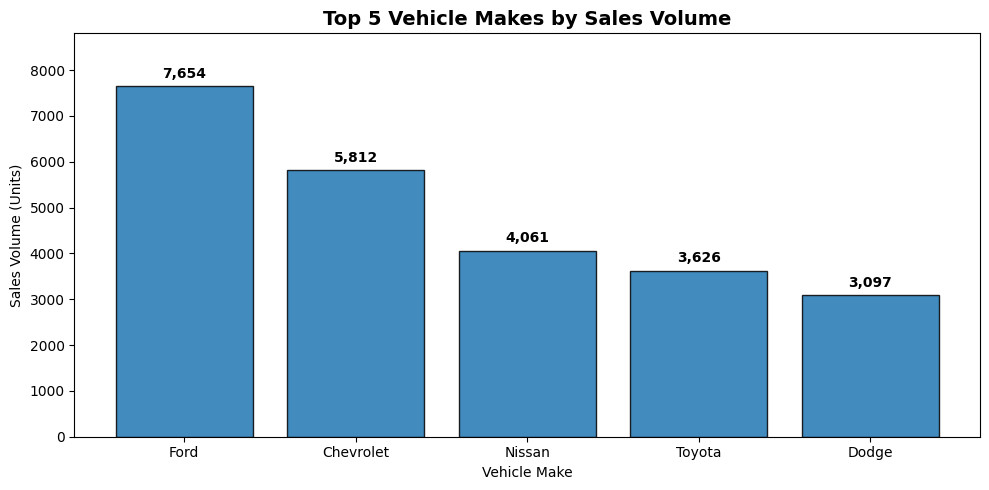

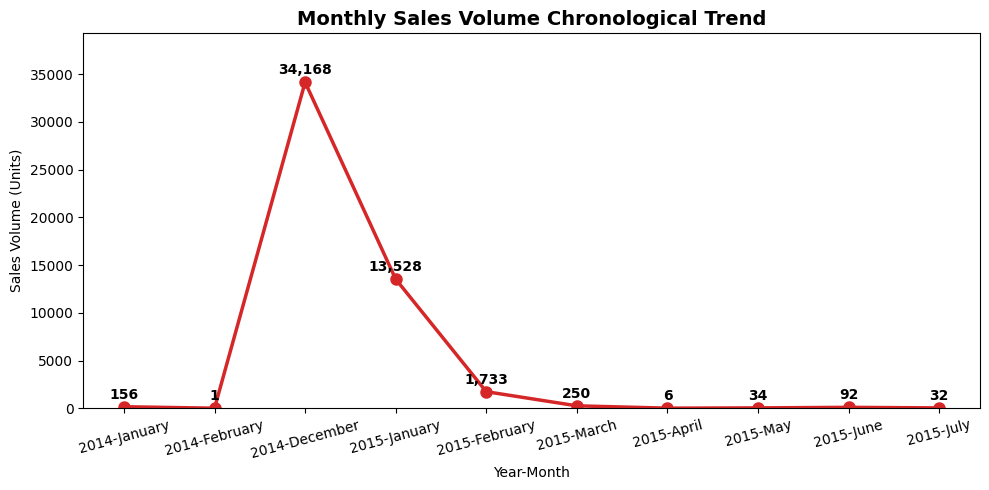

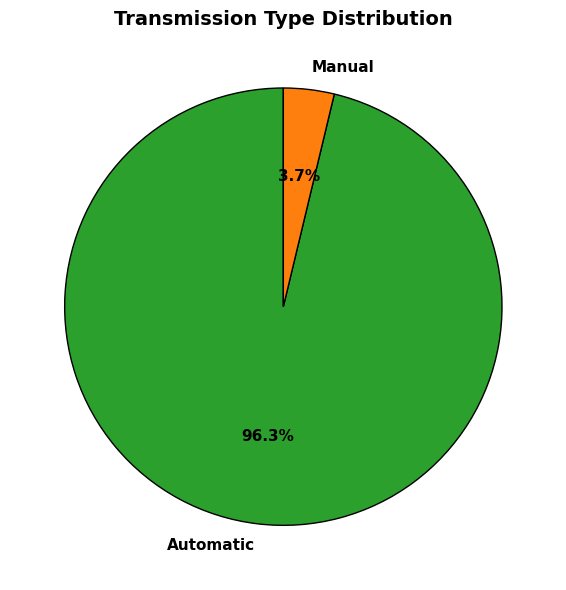

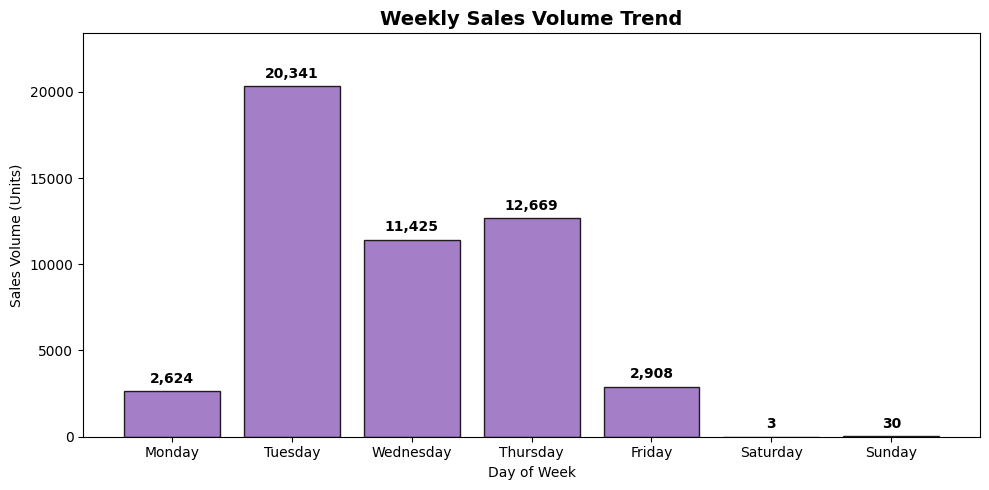

In [23]:
def render_matplotlib_dashboard():
    """Queries database server and plots 4 high-quality charts using Matplotlib."""
    try:
        conn = mysql.connector.connect(host=DB_HOST, port=DB_PORT, user=DB_USER, password=DB_PASSWORD, database=DB_NAME)
        cursor = conn.cursor(dictionary=True)
        
        # Query 1: Top 5 Makes by Sales Volume
        cursor.execute("SELECT make, COUNT(*) AS volume FROM car_sales GROUP BY make ORDER BY volume DESC LIMIT 5")
        top_makes = cursor.fetchall()
        makes = [r['make'] for r in top_makes]
        make_volumes = [r['volume'] for r in top_makes]
        
        # Query 2: Monthly Sales Volumes
        cursor.execute("""
            SELECT CONCAT(YEAR(saledate), '-', MONTHNAME(saledate)) AS period, COUNT(*) AS volume 
            FROM car_sales GROUP BY YEAR(saledate), MONTHNAME(saledate), MONTH(saledate) ORDER BY YEAR(saledate) ASC, MONTH(saledate) ASC
        """)
        monthly_data = cursor.fetchall()
        periods = [r['period'] for r in monthly_data]
        monthly_volumes = [r['volume'] for r in monthly_data]
        
        # Query 3: Transmission Volume Types
        cursor.execute("SELECT transmission, COUNT(*) AS volume FROM car_sales GROUP BY transmission")
        trans_data = cursor.fetchall()
        trans_labels = [r['transmission'].title() for r in trans_data]
        trans_volumes = [r['volume'] for r in trans_data]
        
        # Query 4: Weekly Day Volume
        cursor.execute("""
            SELECT saleday, COUNT(*) AS volume 
            FROM car_sales GROUP BY saleday, WEEKDAY(saledate) ORDER BY WEEKDAY(saledate) ASC
        """)
        weekly_data = cursor.fetchall()
        days = [r['saleday'] for r in weekly_data]
        weekly_volumes = [r['volume'] for r in weekly_data]
        
        cursor.close()
        conn.close()
        
        # Chart 1: Bar Chart of Top Makes
        plt.figure(figsize=(10, 5))
        plt.bar(makes, make_volumes, color='#1f77b4', edgecolor='black', alpha=0.85)
        plt.title('Top 5 Vehicle Makes by Sales Volume', fontsize=14, weight='bold')
        plt.xlabel('Vehicle Make')
        plt.ylabel('Sales Volume (Units)')
        max_val1 = max(make_volumes) if make_volumes else 1
        plt.ylim(0, max_val1 * 1.15)
        offset1 = max_val1 * 0.015
        for idx, val in enumerate(make_volumes):
            plt.text(idx, val + offset1, f"{val:,}", ha='center', va='bottom', weight='bold')
        plt.tight_layout()
        plt.show()
        
        # Chart 2: Line Chart of Monthly Volume Trends
        plt.figure(figsize=(10, 5))
        plt.plot(periods, monthly_volumes, marker='o', color='#d62728', linewidth=2.5, markersize=8)
        plt.title('Monthly Sales Volume Chronological Trend', fontsize=14, weight='bold')
        plt.xlabel('Year-Month')
        plt.ylabel('Sales Volume (Units)')
        plt.xticks(rotation=15)
        max_val2 = max(monthly_volumes) if monthly_volumes else 1
        plt.ylim(0, max_val2 * 1.15)
        offset2 = max_val2 * 0.015
        for idx, val in enumerate(monthly_volumes):
            plt.text(idx, val + offset2, f"{val:,}", ha='center', va='bottom', weight='bold')
        plt.tight_layout()
        plt.show()
        
        # Chart 3: Pie Chart of Transmission Distributions
        plt.figure(figsize=(6, 6))
        plt.pie(trans_volumes, labels=trans_labels, autopct='%1.1f%%', colors=['#2ca02c', '#ff7f0e'], startangle=90,
                       textprops={'fontsize': 11, 'weight': 'bold'}, wedgeprops={'edgecolor': 'black', 'linewidth': 1, 'antialiased': True})
        plt.title('Transmission Type Distribution', fontsize=14, weight='bold')
        plt.tight_layout()
        plt.show()
        
        # Chart 4: Bar Chart of Weekly Volume Trends
        plt.figure(figsize=(10, 5))
        plt.bar(days, weekly_volumes, color='#9467bd', edgecolor='black', alpha=0.85)
        plt.title('Weekly Sales Volume Trend', fontsize=14, weight='bold')
        plt.xlabel('Day of Week')
        plt.ylabel('Sales Volume (Units)')
        max_val4 = max(weekly_volumes) if weekly_volumes else 1
        plt.ylim(0, max_val4 * 1.15)
        offset4 = max_val4 * 0.015
        for idx, val in enumerate(weekly_volumes):
            plt.text(idx, val + offset4, f"{val:,}", ha='center', va='bottom', weight='bold')
        plt.tight_layout()
        plt.show()
    except Error as e:
        print(f"[-] SQL plotting error: {e}")
    except Exception as e:
        print(f"[-] Plotting error: {e}. Make sure matplotlib is installed.")

render_matplotlib_dashboard()